# Set Up

## Mount Google Drive

Ignore if not using Google Collab:

In [1]:
from google.colab import drive

# mount google drive
drive.mount('/content/drive')
%cd /content/drive/My Drive
!git clone https://github.com/FranciscoLozCoding/cooling_with_code.git
%cd cooling_with_code
!git pull

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/My Drive
fatal: destination path 'cooling_with_code' already exists and is not an empty directory.
/content/drive/My Drive/cooling_with_code
Already up to date.


## Import Libraries

In [2]:
%%capture
%pip install shap
%pip install stackstac
%pip install pystac-client
%pip install planetary-computer
%pip install odc-stac
%pip install rioxarray
%pip install geopy
%pip install geopandas

In [3]:
# Supress Warnings
import warnings
warnings.filterwarnings('ignore')

#data science
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
from sklearn.feature_selection import RFECV
from sklearn.model_selection import GridSearchCV
import pickle
import shap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#other
import os

#custom tools
from tools.environment import VALID_SPLIT, RANDOM_STATE, TARGET_VARIABLE
from tools.feature_selection import (
    get_feature_importance,
    plot_feature_importance_comparison,
    perm_importance,
    plot_perm_importance_comparison,
    rfe_importance,
    plot_rfe_importance)
from tools.distribution import plot_target_var_distribution
from tools.preprocess import apply_preprocessing_mixed_buffers, load_and_preprocess_data
from tools.explainer import Explainer
from tools.build_dataset import combine_buffer_datasets

## Import Datasets

Here we will import our version 2 of our dataasets that include energy variables and we will also combine the buffer zone datasets into one.

In [4]:
train_combined, test_combined = combine_buffer_datasets('data/train/v2', 'data/test/v2')

Loading training data: data/train/v2/50m_buffer_dataset.csv
Loading test data: data/test/v2/50m_buffer_test_dataset.csv
Loading training data: data/train/v2/100m_buffer_dataset.csv
Loading test data: data/test/v2/100m_buffer_test_dataset.csv
Loading training data: data/train/v2/150m_buffer_dataset.csv
Loading test data: data/test/v2/150m_buffer_test_dataset.csv
Loading training data: data/train/v2/300m_buffer_dataset.csv
Loading test data: data/test/v2/300m_buffer_test_dataset.csv

Final Training Dataset Shape: (11229, 125)
Final Test Dataset Shape: (1040, 126)


In [5]:
train_combined, test_combined = apply_preprocessing_mixed_buffers(train_combined, test_combined, energy_features=True)


Final Processed Training Dataset Shape: (11229, 284)
Final Processed Testing Dataset Shape: (1040, 285)


# Mixed Buffers RandomForestRegressor

This notebook is for creating a new RandomForestRegressor with a mixture of buffer zones. For details on the train/test dataset refer to our past notebook:
- [09_adding_energy_data](/09_adding_energy_data.ipynb)


## Preprocessing

First, we will seperate the target variable and scale the data.

In [6]:
# Separate features and target
y = train_combined['UHI']
X = train_combined.drop('UHI', axis=1)

# Remove constant columns
X = X.loc[:, X.std() != 0]

#scale
scaler = StandardScaler()
X = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

#split
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=VALID_SPLIT, random_state=RANDOM_STATE
)

#make into df
x_train_df = pd.DataFrame(X_train, columns=X.columns)
x_valid_df = pd.DataFrame(X_valid, columns=X.columns)

## Feature Selection

Next, we will do feature selection. We now have interaction terms and a mixture of variables in different buffer zone measurements, so the dataset is filled with a lot of features that need to be dropped.

In [ ]:
# Base Random Forest Model
rf = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)

# Recursive Feature Elimination with Cross-Validation
rfe = RFECV(estimator=rf, step=1, cv=5, scoring="r2", n_jobs=-1)

# Fit to training data
rfe.fit(x_train_df, y_train)

# Get selected features
selected_features = x_train_df.loc[:, rfe.support_]

# Get names of selected features
selected_feature_names = x_train_df.columns[rfe.support_]

# Print selected feature names
print("Selected Features:", list(selected_feature_names))

In [7]:
# save the selected features so we don't have to run again
selected_feature_names=['50m_NDWI', '50m_1NPCRI', '50m_1Building_Construction_Year',
                        '50m_1Ground_Elevation', '50m_1Fuel_Oil_2_Use_kBtu', '50m_1Fuel_Oil_4_Use_kBtu',
                        '50m_1Electricity_Use_Grid_Purchase_kBtu', '50m_Building_Wind_Y', '50m_Elevation_Wind_Y',
                        '50m_Traffic_NDVI', '100m_NDVI', '100m_SI', '100m_NPCRI', '100m_Coastal_Aerosol',
                        '100m_Building_Construction_Year', '100m_Elevation_Wind_X', '100m_BldgHeight_Count',
                        '100m_Humidity_NDVI', '100m_Water_Use_Per_Area', '100m_Fuel_Dependency',
                        '150m_Building_Wind_X', '150m_Elevation_Wind_Y', '150m_Temp_BuildingDensity',
                        '150m_Building_Aspect_Ratio', '150m_Permeable_Impermeable_Ratio', '150m_Water_Use_Per_Area',
                        '150m_Fuel_Dependency', '300m_NDWI', '300m_SI', '300m_NPCRI', '300m_Coastal_Aerosol',
                        '300m_Building_Count', '300m_Building_Construction_Year', '300m_Ground_Elevation',
                        '300m_Weather_Normalized_Site_EUI_kBtu_ft2', '300m_Fuel_Oil_2_Use_kBtu', '300m_Fuel_Oil_4_Use_kBtu',
                        '300m_Direct_GHG_Emissions_MetricTons_CO2e', '300m_Water_Use_All_Sources_kgal', '300m_Building_Wind_X',
                        '300m_Building_Wind_Y', '300m_Elevation_Wind_X', '300m_Elevation_Wind_Y', '300m_BldgHeight_Count',
                        '300m_BuildingDensity_NDVI', '300m_Traffic_NDVI', '300m_Temp_BuildingDensity', '300m_Traffic_NDBI',
                        '300m_BuildingAge_Temp', '300m_Building_Aspect_Ratio', '300m_Urban_Material_Index', '300m_Permeable_Impermeable_Ratio',
                        '300m_Land_Surface_Albedo', '300m_Canopy_Cover_Ratio', '300m_Soil_Moisture_Index', '300m_Traffic_Heat_Emission',
                        '300m_GHG_Proxy', '300m_Energy_Use_Per_Building', '300m_Fuel_Dependency']

Here we see the features that were selected. These features maximized the cross-validation score. Now let's select them for our training/validation set.

In [8]:
# select features
x_train_selected = pd.DataFrame(X_train, columns=x_train_df.columns)[selected_feature_names]
x_valid_selected = pd.DataFrame(X_valid, columns=x_train_df.columns)[selected_feature_names]

Now that we have the selected features, let's re do the scaler so that the saved scaler only accepts the selected features.

In [9]:
# Separate features and target
y = train_combined['UHI']
X = train_combined.drop('UHI', axis=1)

# Remove constant columns
X = X.loc[:, X.std() != 0]

# only selected
X = X[selected_feature_names]

#scaler
scaler = StandardScaler()
scaler.fit_transform(X)

array([[-0.36502564,  1.0452182 ,  0.31687682, ..., -0.31552992,
        -0.21589026,  0.29897671],
       [-0.49237841,  1.00075169,  0.3115036 , ..., -0.3223217 ,
        -0.21348207,  0.30589169],
       [-0.59826107,  0.95394058,  0.30177366, ..., -0.32329196,
        -0.21317333,  0.30589169],
       ...,
       [-3.00323495, -2.35688867, -5.56959407, ..., -0.31731005,
         7.52007469,  0.19950779],
       [-2.9821176 , -2.38442392, -5.56959407, ..., -0.31731005,
         7.52007469,  0.19950779],
       [-2.97101092, -2.41880827, -5.56959407, ..., -0.31731005,
         7.52007469,  0.19950779]])

## Hyperparameter Tuning

Now we will tune the Random Forest Regressor hyperparemeters using `GridSearchCV`.

In [ ]:
# Define hyperparameter grid
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
    "bootstrap": [True, False]
}

# Initialize model
rf_model = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)

# Grid search with selected features
grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=2
)

# Fit grid search to the **selected features only**
grid_search.fit(x_train_selected, y_train)

# Best parameters
print("Best Hyperparameters:", grid_search.best_params_)
print("Best R-squared Score:", grid_search.best_score_)

In [ ]:
# save the best params so we don't have to run again
best_hparams = {'bootstrap': False, 'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}

Here we see the hyper params for the best model and the R-squared it got. Let's retrieve the best model.

In [12]:
# best model, skip if model was already generated
model_pkl = 'models/mixed_buffers_RandomForestRegressor/mixed_buffers_RandomForestRegressor_model.pkl'
model_pkl = 'mixed_buffers_RandomForestRegressor_model.pkl' #TEMP
if not os.path.exists(model_pkl):
  best_rf_model = grid_search.best_estimator_
else:
  with open(model_pkl, 'rb') as f:
    best_rf_model = pickle.load(f)

## In-Sample Evaluation

In [13]:
# Make predictions on the training data
insample_predictions = best_rf_model.predict(x_train_selected)

# calculate R-squared score for in-sample predictions
print(f"In-Sample Evaluation:")

insample_r2 = r2_score(y_train, insample_predictions)
print(f"  Mixed buffers zone R-squared: {insample_r2}")

In-Sample Evaluation:
  Mixed buffers zone R-squared: 1.0


## Out-Sample Evaluation

In [14]:
# Make predictions on the validation data
outsample_predictions = best_rf_model.predict(x_valid_selected)

# calculate R-squared score for in-sample predictions
print(f"Out-Sample Evaluation:")

outsample_r2 = r2_score(y_valid, outsample_predictions)
print(f"  Mixed buffers zone R-squared: {outsample_r2}")

Out-Sample Evaluation:
  Mixed buffers zone R-squared: 0.9696851994826778


# Challenge Submission

We will now submit our mixed buffers `RandomForestRegressor` model to the challenge.
>NOTE: We can have multiple submissions.

In [16]:
# Remove lat and lon, for now will be combined with predicted UHI later for submission
lon = test_combined['Longitude'].values
lat = test_combined['Latitude'].values
test_dataset = test_combined.drop(columns=['Longitude', 'Latitude'])

#select features
test_dataset = test_dataset[selected_feature_names]

#scale
x_test = pd.DataFrame(scaler.transform(test_dataset),
                      columns=test_dataset.columns,
                      index=test_dataset.index).values

# Model prediction
test_predictions = best_rf_model.predict(x_test)

# combine predictions with lat and lon
submission_df = pd.DataFrame({
    'Longitude': lon,
    'Latitude': lat,
    'UHI Index': test_predictions
})
submission_df

,Longitude,Latitude,UHI Index
0,-73.971665,40.788763,0.964205
1,-73.971928,40.788875,0.964318
2,-73.967080,40.789080,0.965934
3,-73.972550,40.789082,0.963806
4,-73.969697,40.787953,0.960014
...,...,...,...
1035,-73.919388,40.813803,1.037145
1036,-73.931033,40.833178,1.039613
1037,-73.934647,40.854542,1.040093
1038,-73.917223,40.815413,1.037831


Save the submission dataframe to submit into challenge portal:

In [ ]:
submission_df.to_csv("mixed_buffers_RandomForestRegressor_model_submission.csv", index=False)

Score We Received:

![submission score](https://github.com/FranciscoLozCoding/cooling_with_code/blob/main/images/mixed_buffers_RandomForestRegressor_model_score.jpeg?raw=1)

Our Mixed Buffer RandomForestRegressor did better than our 300m tuned RandomForestRegressor.

# Understanding the Results

Now we will use SHAP to understand the results. SHAP can show us feature importance, ranking, understand feature vs. prediction relationships, and can even explain individual predictions. This is what we need to understand the drivers of the Urban Heat Island phenomenon.

In [17]:
# Initialize SHAP Explainer for Random Forest Model
explainer = Explainer(
    model=best_rf_model,
    explainer_type=shap.TreeExplainer,
    X=test_dataset,
    feature_names=test_dataset.columns
)

## Summary Plot

Here, we will see the most important features and how do features impact predictions. This is how to interpret the plot:

- Each **dot** represents a single data point from our dataset.
- **X-Axis (`SHAP Value`)**: The **impact** of a feature on the prediction.
- **Y-Axis (Feature Names)**: The **most important features** ranked from top to bottom.
- **Color (Red to Blue)**: The **feature value** (High = Red, Low = Blue).
  - **Red** = High feature value.
  - **Blue** = Low feature value.

1. **Feature Importance**  
   - Features are **ranked by importance** (most important at the top).
   - The **wider** the spread on the X-axis, the more that feature **influences predictions**.

2. **Direction of Influence**  
   - **Positive SHAP values (Right Side)**: Feature **increases** the prediction.
   - **Negative SHAP values (Left Side)**: Feature **decreases** the prediction.

3. **Effect of Feature Value (Color Gradient)**  
   - **Red (High Value)** trends to the **right**? High values **increase** predictions.
   - **Blue (Low Value)** trends to the **left**? Low values **decrease** predictions.

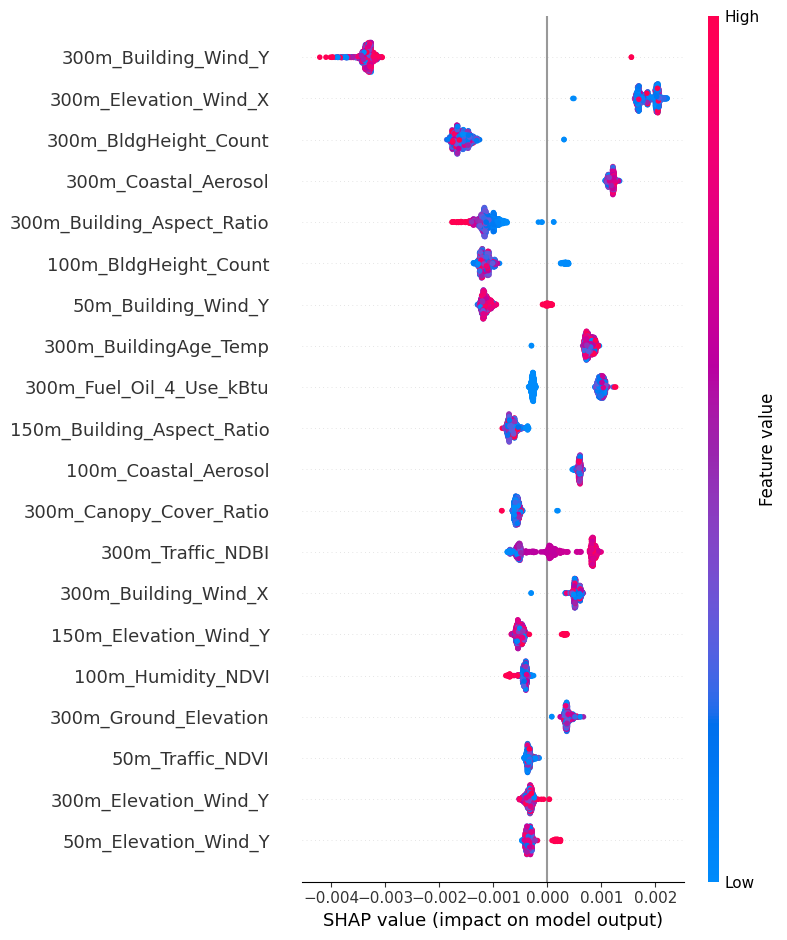

In [18]:
explainer.summary_plot()

>TODO: explanation

## Bar Plot

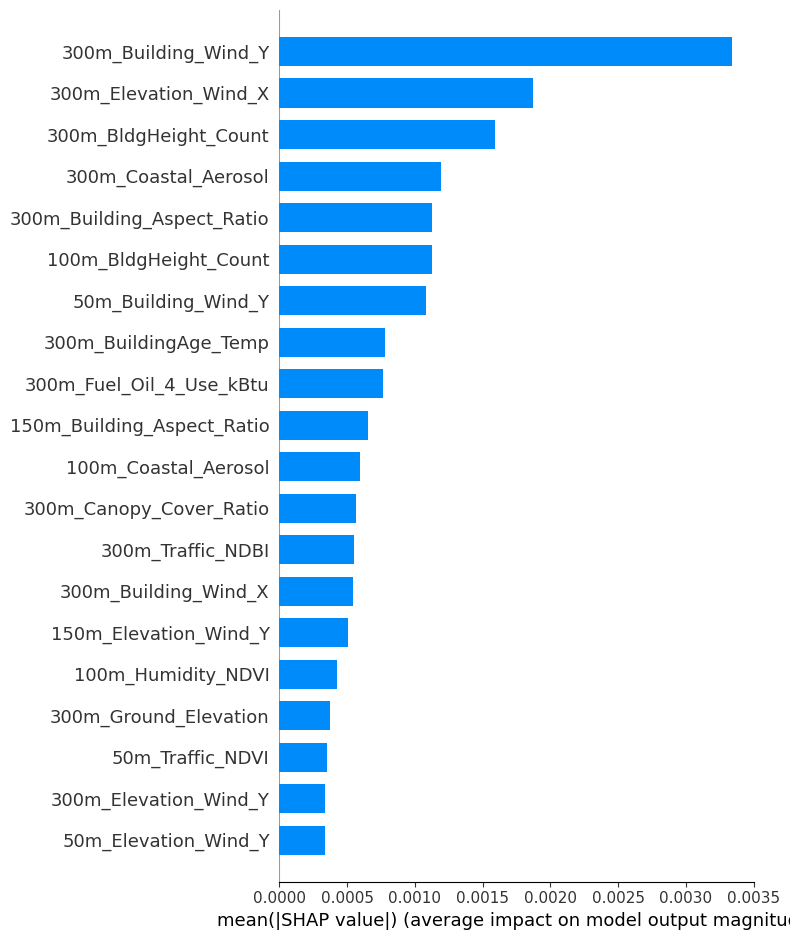

In [19]:
explainer.bar_plot()

>TODO: explanation

## Dependence Plot

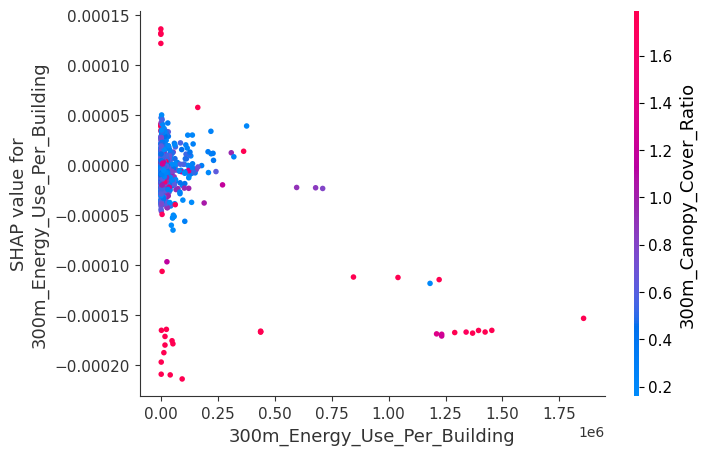

In [20]:
explainer.dependence_plot("300m_Energy_Use_Per_Building")

>TODO: explanation

## Force Plot

Finally, we will explain an individual prediction. We can do this one by one for all predictions, but for now we will do the first one.

In [21]:
#location index
record_index = 0

In [22]:
#show location
submission_df.iloc[record_index, :]

,0
Longitude,-73.971665
Latitude,40.788763
UHI Index,0.964205


In [23]:
shap.initjs()
explainer.force_plot(index=record_index)

>TODO: explanation

# Summary Table

In [24]:
# create the summary table
models = ['mixed_buffers_RandomForestRegressor_model']

data = {
    'Model': models,
    'Training R-squared': [insample_r2],
    'Validation R-squared': [outsample_r2]
}

summary_df = pd.DataFrame(data)
summary_df

,Model,Training R-squared,Validation R-squared
0,mixed_buffers_RandomForestRegressor_model,1.0,0.969685


# Save The Model

Now we will save both the model and the scaler.

In [25]:
# Save the model and scaler to files
with open('mixed_buffers_RandomForestRegressor_model.pkl', 'wb') as f:
    pickle.dump(best_rf_model, f)
with open('mixed_buffers_standard_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Conclusion

>TODO

# NOTES

- Using the features selected by Random forest does better than doing feature selectio using my ResNet model
- Using smaller neaurons in my first later gave me a worse score, so I had to increase it. Meaning Increasing the neuron count helped capture more detailed patterns in the data.
- ResNet helped in making my neural network better.
- Using Adaptive Learning Rate helped in making my neural network better
- The mixed buffer dataset improved my Random Forest model
- Also using the mixed buffer dataset helped improve my neural network model
- the neural network with variables from...
   - v1 mixed buffer dataset got a 0.95 in out-sample and 0.97 in in-sample (ORIGINAL model)
   - v2 mixed buffer dataset that were RFECV selected got a 0.63 in out-sample and a 0.84 in in-sample (model fine tuned for energy vars)
   - v2 mixed buffer dataaset that were manually selected (option 1)...
      - got a 0.95 in out-sample and 0.97 in in-sample (ORIGINAL model)
      - got a 0.78 in out-sample and 0.95 in in-sample (model fine tuned for energy vars)
   - v2 mixed buffer dataaset that were manually selected (option 2)...
      - got a 0.95 in out-sample and 0.96 in in-sample (ORIGINAL model)
      - got a 0.79 in out-sample and 0.96 in in-sample (model fine tuned for energy vars)
- v1 mixed buffer dataset with ORIGINAL model is the best, less overfitting